In [1]:
from __future__ import annotations

from pathlib import Path
import string

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

In [2]:
plt.rcParams['font.family']='Arial'

plt.rc('axes', labelsize=10)
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=12) 
set_dpi=600

In [11]:
observed_color = "blue"
predicted_color = "#00C853"
level_colors = {3: "lightgreen", 4: "green"}
level_labels = {3: "Level 3", 4: "Level 4"}
region_order = [
    "Seoul", "Busan", "Daegu", "Incheon", "Gwangju", "Daejeon",
    "Ulsan", "Gyeonggi", "Gangwon", "Chungbuk", "Chungnam",
    "Jeonbuk", "Jeonnam", "Gyeongbuk", "Gyeongnam", "Jeju",
]
region_code= {region: f"G{i}" for i, region in enumerate(region_order, start=1)}

## Observed and predicted data

In [5]:
actual = pd.read_excel("../data/Final_heat_region.xlsx", usecols=["date", "region", "case", "year", "wbgt"]).rename(columns={"case": "observed"})
predicted = pd.read_excel("../results/Model_result.xlsx", usecols=["date", "region", "predicted"], sheet_name='LSTM')

actual["date"] = pd.to_datetime(actual["date"], errors="coerce")
predicted["date"] = pd.to_datetime(predicted["date"], errors="coerce")
actual["observed"] = pd.to_numeric(actual["observed"], errors="coerce")
predicted["predicted"] = (pd.to_numeric(predicted["predicted"], errors="coerce").clip(lower=0))

actual = actual.loc[actual["year"].isin([2022, 2023])].copy()
merged = actual.merge(predicted, on=["date", "region"], how="left", validate="one_to_one")
merged["year"] = merged["date"].dt.year
merged = merged.sort_values(["region", "date"]).reset_index(drop=True)

## Regional and national warning levels

In [13]:
def regional_level(values: pd.Series) -> pd.Series:
    clipped = pd.to_numeric(values, errors="coerce").clip(lower=0)
    levels = pd.cut(
        clipped,
        bins=[-np.inf, 1, 6, 19, np.inf],
        labels=[1, 2, 3, 4],
        right=False,
    )
    return levels.astype("Int64")


def national_level(row: pd.Series, n_regions: int = 16) -> float:
    if row["N_observed"] != n_regions:
        return np.nan
    n2, n3, n4 = row["N_Level2"], row["N_Level3"], row["N_Level4"]
    if (n4 >= 1) or (n3 >= 4) or (n3 >= 3 and n2 >= 2) or (n3 >= 2 and n2 >= 8):
        return 4
    if (n3 >= 1) or (n2 >= 7):
        return 3
    if 1 <= n2 <= 6:
        return 2
    return 1


def add_warning_levels(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    regional = data.copy()
    regional["observed_level"] = regional_level(regional["observed"])
    regional["predicted_level"] = regional_level(regional["predicted"])

    regional["date"] = pd.to_datetime(regional["date"])
    regional["apparent"] = pd.to_numeric(regional["wbgt"], errors="coerce") + np.where(regional["date"].lt(pd.Timestamp("2022-06-02")), 3.5, 3.0)
    regional = regional.sort_values(["region", "year", "date"])
    g = regional.groupby(["region", "year"], sort=False)
    low = regional["apparent"].ge(33) & g["apparent"].shift(1).ge(33)
    strong = regional["apparent"].ge(35) & g["apparent"].shift(1).ge(35)
    regional["kma_level"] = np.select([strong, low], [2, 1], default=0)

    level_counts = (
        regional.dropna(subset=["predicted_level"])
        .groupby(["date", "predicted_level"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3, 4], fill_value=0)
    )
    level_counts.columns = ["N_Level1", "N_Level2", "N_Level3", "N_Level4"]
    level_counts["N_observed"] = regional.groupby("date")["predicted"].count()
    level_counts["predicted_level"] = level_counts.apply(national_level, axis=1)

    national_cases = regional.groupby("date").agg(
        observed=("observed", lambda x: x.sum(min_count=1)),
        predicted=("predicted", lambda x: x.sum(min_count=len(region_code))),
    )
    
    obs_counts = (
        regional.dropna(subset=["observed_level"])
        .groupby(["date", "observed_level"], observed=False).size().unstack(fill_value=0)
        .reindex(columns=[1, 2, 3, 4], fill_value=0)
    )
    obs_counts.columns = ["N_Level1", "N_Level2", "N_Level3", "N_Level4"]
    obs_counts["N_observed"] = regional.groupby("date")["observed"].count()
    obs_counts["observed_level"] = obs_counts.apply(national_level, axis=1)

    national = national_cases.join(level_counts[["predicted_level"]]).join(
        obs_counts[["observed_level"]]
    ).reset_index()
    national["year"] = national["date"].dt.year
    apparent_max = regional.groupby("date")["apparent"].max().reindex(national["date"]).to_numpy()
    national["apparent"] = apparent_max
    national = national.sort_values("date")
    gnat = national.groupby("year", sort=False)
    low = national["apparent"].ge(33) & gnat["apparent"].shift(1).ge(33)
    strong = national["apparent"].ge(35) & gnat["apparent"].shift(1).ge(35)
    national["kma_level"] = np.select([strong, low], [2, 1], default=0)
    return regional, national

In [14]:
def add_plot_positions(data: pd.DataFrame, years: list[int], gap_days: int = 0) -> pd.DataFrame:
    x = data.copy()
    plot_positions = pd.Series(np.nan, index=x.index, dtype="float64")
    offset = 0
    for year in years:
        mask = x["year"].eq(year)
        dates = x.loc[mask, "date"]
        if dates.empty:
            continue
        day_position = (dates - dates.min()).dt.days
        plot_positions.loc[mask] = (day_position + offset).astype(float)
        offset += int(day_position.max()) + 1 + gap_days
    x["plot_x"] = plot_positions
    return x


def plot_series_by_year(ax: plt.Axes, data: pd.DataFrame, years: list[int], dot_size: int = 10) -> None:
    for year in years:
        x = data.loc[data["year"].eq(year)].sort_values("date")
        ax.scatter(x["plot_x"], x["observed"], color=observed_color, s=dot_size, alpha=1, zorder=3)
        ax.bar(x["plot_x"], x["predicted"], width=0.75, color=predicted_color, alpha=1, edgecolor="none", zorder=2, label="Estimated cases"
    )


def style_date_axis(ax: plt.Axes, data: pd.DataFrame, years: list[int], position) -> None:
    tick_positions, tick_labels = [], []

    for year in years:
        y = data.loc[data["year"].eq(year)].sort_values("date")
        if y.empty:
            continue

        month_ticks = y.loc[y["date"].dt.day.eq(1)]
        tick_positions.extend(month_ticks["plot_x"].tolist())
        tick_labels.extend(month_ticks["date"].dt.strftime("%b. %d").tolist())

        year_center = (y["plot_x"].min() + y["plot_x"].max()) / 2
        ax.text(year_center, position, str(year), transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=11, fontweight="bold", clip_on=False)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.grid(axis="y", color="0.88", linewidth=0.6, linestyle="--", zorder=0)
    ax.margins(x=0.01)

def _warning_ranges(data: pd.DataFrame, column: str, minimum: int = 1):
    x = data[["date", "plot_x", column]].dropna().sort_values("date").copy()
    x = x[x[column] >= minimum]
    if x.empty:
        return []
    x["group"] = ((x[column] != x[column].shift()) |
                  (x["date"].diff().dt.days != 1)).cumsum()
    return [(g["plot_x"].iloc[0] - 0.5, g["plot_x"].iloc[-1] + 0.5,
             int(g[column].iloc[0])) for _, g in x.groupby("group")]

In [15]:
def draw_warning_panel(ax: plt.Axes, data: pd.DataFrame, show_ylabels: bool = True) -> None:
    kma_colors = {1: "orange", 2: "red"}
    proposed_colors = {3: "lightgreen", 4: "green"}
    observed_colors = {3: "lightblue", 4: "blue"}

    for start, end, level in _warning_ranges(data, "kma_level"):
        ax.axvspan(start, end, ymin=2 / 3, ymax=1, color=kma_colors[level], lw=0)
    for start, end, level in _warning_ranges(data, "predicted_level", minimum=3):
        ax.axvspan(start, end, ymin=1 / 3, ymax=2 / 3, color=proposed_colors[level], lw=0)
    for start, end, level in _warning_ranges(data, "observed_level", minimum=3):
        ax.axvspan(start, end, ymin=0, ymax=1 / 3, color=observed_colors[level], lw=0)

    ax.set_ylim(0, 3)
    ax.axhline(1, color="black", lw=0.7)
    ax.axhline(2, color="black", lw=0.7)
    ax.set_yticks([2.5, 1.5, 0.5])
    ax.set_yticklabels(["KMA", "Estimated", "Observed"] if show_ylabels else [], fontsize=12)
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    ax.grid(False)


def separated_legend_handles() -> list:
    return [
        Patch(color="orange", label="KMA Low warning"),
        Patch(color="red", label="KMA Strong warning"),
        Patch(color="lightgreen", label="Level 3(Esti.)"),
        Patch(color="green", label="Level 4(Esti.)"),
        Patch(color="lightblue", label="Level 3(Obs.)"),
        Patch(color="blue", label="Level 4(Obs.)"),
        Patch(color=predicted_color, label="Estimated cases"),
        # Line2D([], [], color=PREDICTED_COLOR, lw=1.7, label="Predicted cases"),
        Line2D([], [], color=observed_color, marker="o", linestyle="None", markersize=4, label="Observed cases"),
    ]

## Prepare data

In [16]:
regional, national = add_warning_levels(merged)

print(f'Regional rows: {len(regional):,}')
print(f'National rows: {len(national):,}')

Regional rows: 4,288
National rows: 268


## National plotting function

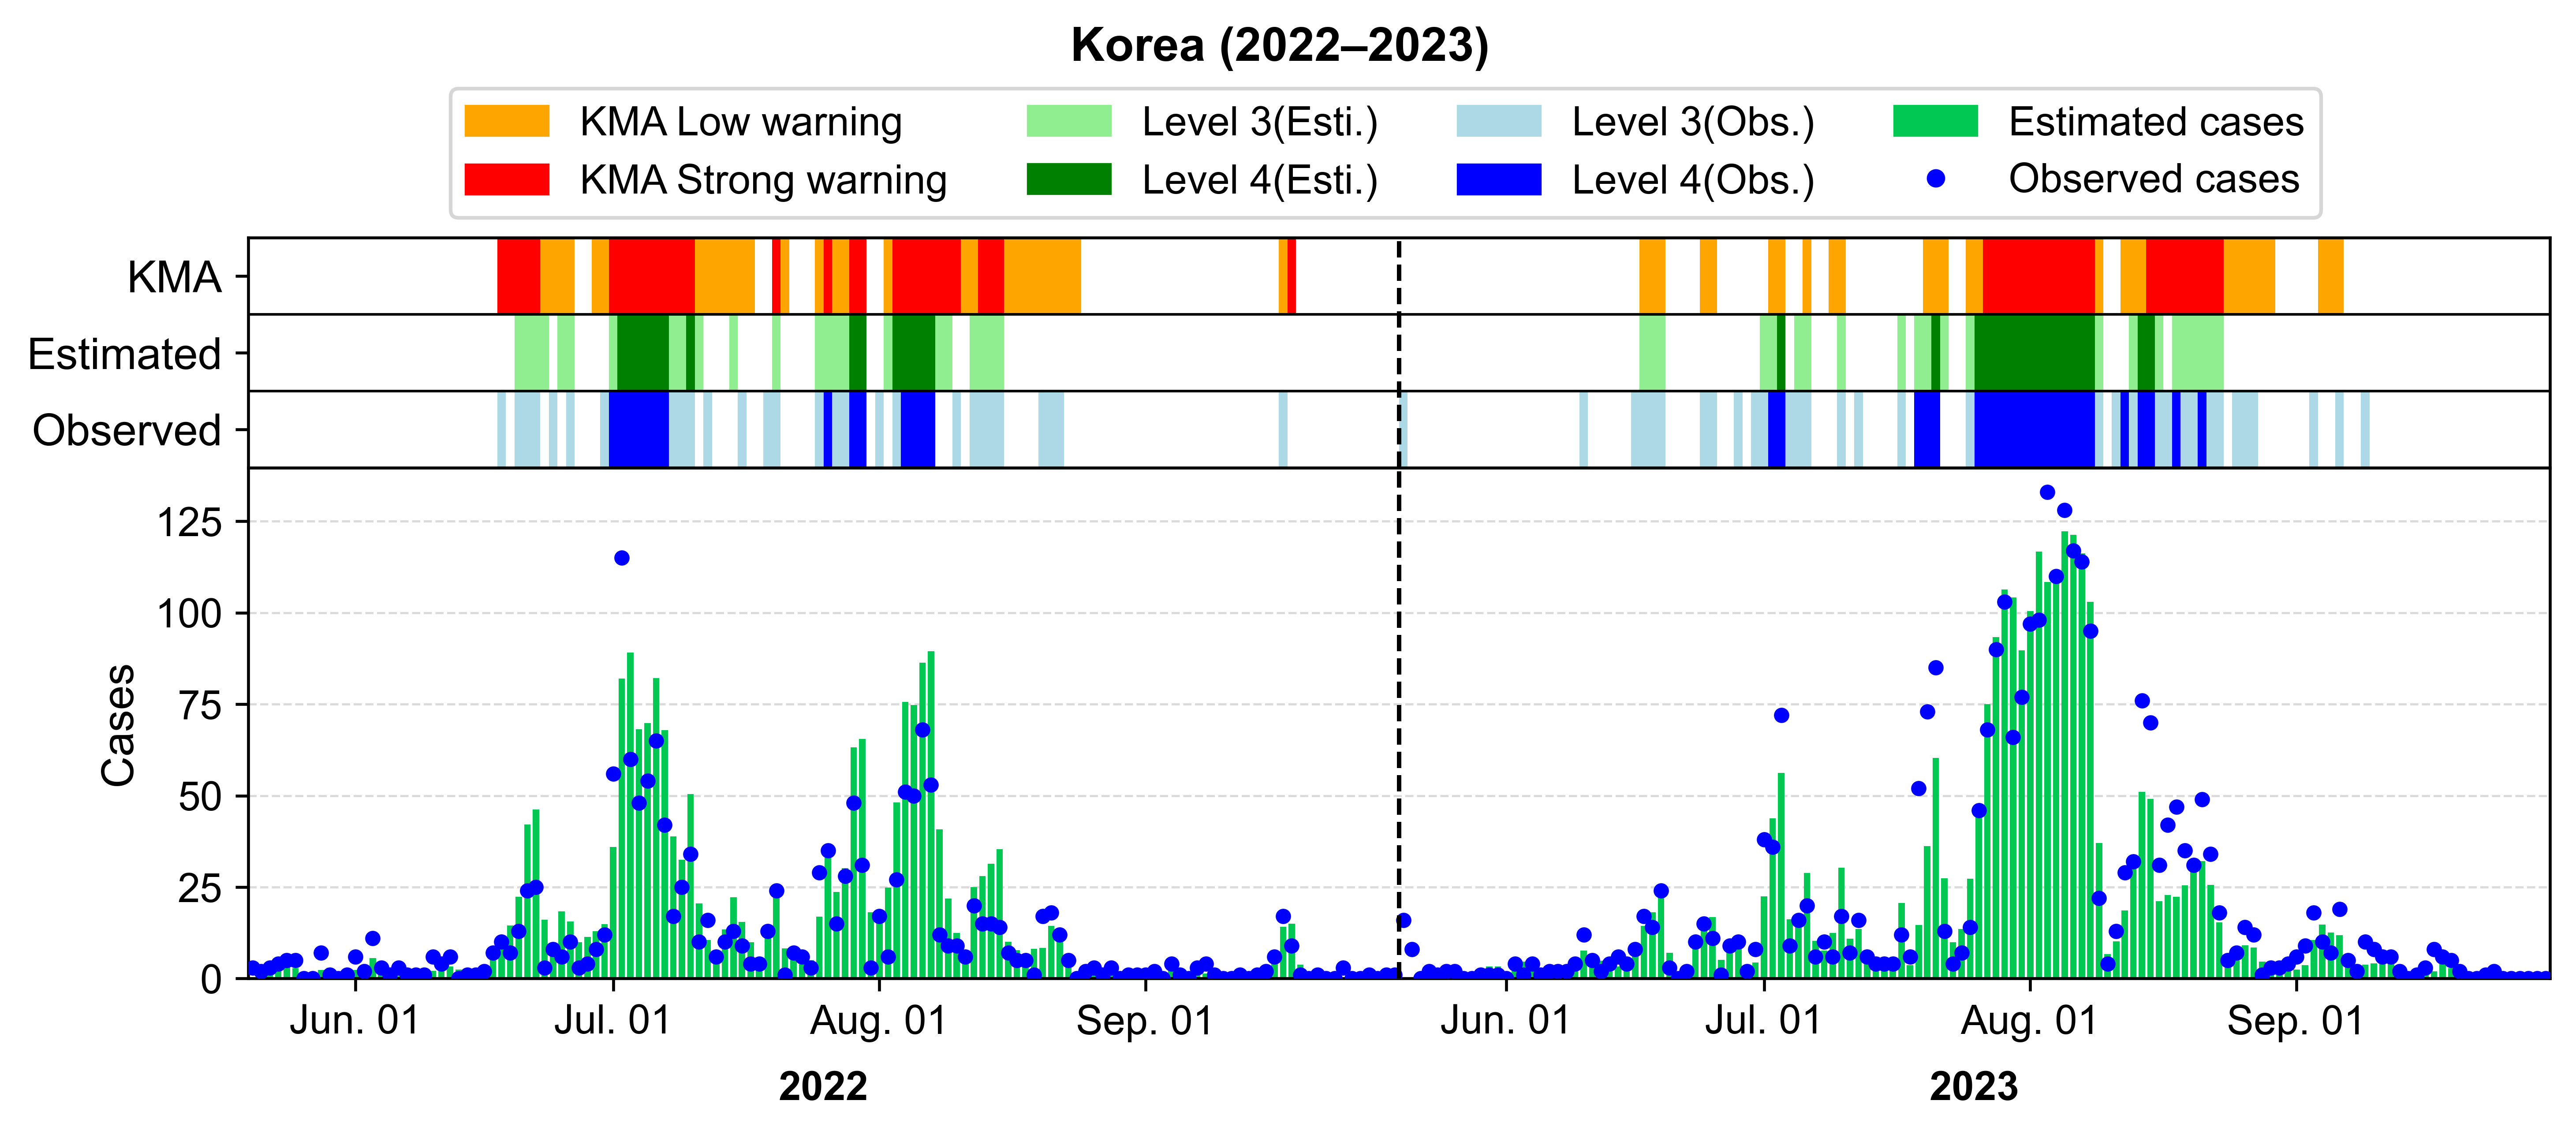

In [20]:
data=national
years=[2022, 2023 ]
x = add_plot_positions(data.loc[data["year"].isin(years)].copy(), years, gap_days=0)
fig = plt.figure(figsize=(10, 4), dpi=600)
grid = fig.add_gridspec(2, 1, height_ratios=[0.9, 2], hspace=0)
ax_warning = fig.add_subplot(grid[0])
ax_case = fig.add_subplot(grid[1], sharex=ax_warning)
ax_case.tick_params(axis="x", labelsize=11)
ax_case.tick_params(axis="y", labelsize=11)
ax_case.set_xlim(x["plot_x"].min() - 0.5, x["plot_x"].max() + 0.5)
draw_warning_panel(ax_warning, x, show_ylabels=True)
plot_series_by_year(ax_case, x, years, 10)
for year in years[1:]:
    year_start = x.loc[x["year"].eq(year), "plot_x"].min()
    if pd.notna(year_start):
        boundary = year_start - 0.5
        ax_warning.axvline(boundary, color="black", linestyle="--", linewidth=1.2, zorder=10)
        ax_case.axvline(boundary, color="black", linestyle="--", linewidth=1.2, zorder=10)
style_date_axis(ax_case, x, years, -0.18)
ax_case.set_ylabel("Cases", fontsize=12)
ax_case.grid(axis="y", color="0.86", ls="--", lw=0.6)
fig.suptitle(f"Korea ({'–'.join(map(str, years))})", fontsize=13, fontweight="bold", y=1.02)
fig.legend(handles=separated_legend_handles(), loc="upper center", bbox_to_anchor=(0.54, 0.98),
            ncol=4, frameon=True, fontsize=11)
fig.subplots_adjust(top=0.82, bottom=0.12, left=0.11, right=0.98)
fig.savefig("../figure/warning_comparison_national.jpg", dpi=600, bbox_inches="tight")
plt.show()

## Regional plotting function

In [19]:
years=[2022,2023]
data=regional

fig = plt.figure(figsize=(12, 25), dpi=600)
outer = fig.add_gridspec(8, 2, hspace=0.5, wspace=0.22)
for idx, region in enumerate(region_order):
    row, col = divmod(idx, 2)
    inner = outer[row, col].subgridspec(2, 1, height_ratios=[0.9, 2.3], hspace=0)
    ax_warning = fig.add_subplot(inner[0])
    ax_case = fig.add_subplot(inner[1], sharex=ax_warning)
    x = data.loc[data["region"].eq(region) & data["year"].isin(years)].copy()
    x = add_plot_positions(x, years)
    draw_warning_panel(ax_warning, x, show_ylabels=(col == 0))
    plot_series_by_year(ax_case, x, years, 6)
    for year in years[1:]:
        year_start = x.loc[x["year"].eq(year), "plot_x"].min()
        if pd.notna(year_start):
            boundary = year_start - 0.5
            ax_warning.axvline(boundary, color="black", linestyle="--", linewidth=0.8, zorder=10)
            ax_case.axvline(boundary, color="black", linestyle="--", linewidth=0.8, zorder=10)
    style_date_axis(ax_case, x, years, -0.40)
    ax_case.tick_params(axis="y", labelsize=11)
    ax_case.tick_params(axis="x", labelsize=11, rotation=30)
    ax_case.set_ylabel("Cases", fontsize=12)
    ax_case.grid(axis="y", color="0.88", ls="--", lw=0.5)
    ax_warning.text(0.0, 1.05, string.ascii_uppercase[idx], transform=ax_warning.transAxes, ha="left", va="bottom", fontsize=12 , fontweight="bold")

    # Region name: centered
    ax_warning.text( 0.5, 1.05, f"{region} ({region_code[region]})", transform=ax_warning.transAxes, ha="center", va="bottom", fontsize=12,fontweight="bold")
    
# fig.suptitle(f"Regional warning periods and heat-illness cases, {'–'.join(map(str, years))}", fontsize=13, fontweight="bold", y=0.997)
fig.legend(handles=separated_legend_handles(), loc="upper center", bbox_to_anchor=(0.5, 0.998), ncol=4, frameon=True, fontsize=11)
fig.subplots_adjust(top=0.96, bottom=0.025, left=0.08, right=0.99)
fig.savefig(f"../figure/warning_comparison_regional.jpg", dpi=600, bbox_inches="tight")
plt.show()